In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from msfm.utils import prior, parameters, files, logger, observation, scales
from msi.utils import preprocessing, plotting

In [3]:
use_flow = True

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

### v10

In [4]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# # params = ["Om", "s8"]

In [5]:
# with_lensing = False
# with_clustering = True
# # params = ["Om", "s8", "w0", "bg", "n_bg"]
# params = ["Om", "s8"]

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

In [7]:
# # conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v10/cls"

In [8]:
# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 50_000
# n_steps = 100_000
# cosine_decay = False
# # cosine_decay = True

# # label = f"lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize},pca={pca_components},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}"

# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"

# # file_label = "high_noise"
# # file_label = "no_noise"
# # file_label = "legacy"
# # file_label = "legacy,fixed_binning"
# # file_label = "legacy,l_min=0"
# # file_label = "high_noise"
# # file_label = "no_ell_in_bins_[0,10]"
# # file_label = "no_ell_in_bins_[:8]"
# # file_label = "no_ell_in_bins_[:2]"
# # file_label = "no_ell_in_bins_[-8:]"
# # file_label = "standard"
# # file_label = "legacy,corrected"
# # file_label = "legacy,corrected,l_min"
# # file_label = "default,1%noise"
# # file_label = "10%noise"
# # file_label = "default"
# # file_label = "default,1%noise"
# # file_label = "default,10%noise"
# # file_label = "default,naive_noise"
# # file_label = "sanity_check_2"
# # file_label = "default,from_maps"

# # file_label = "default,new"

# # file_label = "z_consistency,auto"
# # file_label = "z_consistency,26"
# # file_label = "z_consistency,30"
# # file_label = "z_consistency,33"
# # file_label = "z_consistency,35"

# file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# file_label += "_flock"
# # file_label += "_octant"

# # file_label = "hard_cut"
# # file_label = "smoothing_big,noise_small"
# # file_label = "smoothing_small,noise_big"

# label = os.path.join(label, file_label)
# loss = "mutual_info"
# pred_file = os.path.join(out_dir, loss, label, "preds.h5")

### v11

In [9]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# # params = ["Om", "s8"]

In [10]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [11]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

In [12]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v11/cls"

# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 50_000
# n_steps = 100_000
# cosine_decay = False

# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"
# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"

# # file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# file_label = "28mpc"
# # file_label += "octant"

# # file_label += "_" + str(params).replace(" ", "").replace("'", "")

# label = os.path.join(label, file_label)
# loss = "mutual_info"

# pred_file = os.path.join(out_dir, loss, label, "preds.h5")
# print(pred_file)

### v12

In [13]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

In [14]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [15]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [16]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v12/cls"

# file_label = "/16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# # file_label += "octant"
# # file_label += "_no_cross_z"

# n_params = len(params)
# apply_log = True
# standardize = False

# pca_components = None

# # n_steps = 50_000
# n_steps = 100_000
# # n_steps = 200_000
# cosine_decay = False
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log={apply_log},cosine={cosine_decay},steps={n_steps}"
# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"
# label += file_label
# loss = "mutual_info"
# pred_file = os.path.join(out_dir, loss, label, "preds.h5")

# # label = f"cca/lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize}"
# # label = os.path.join(label, file_label)
# # pred_file = os.path.join(out_dir, label, "preds.h5")

# print(pred_file)

### v13

In [17]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# # params = ["Om", "s8"]

In [18]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [19]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

In [20]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v13/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v13/extended"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v13/cls"

# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 100_000
# n_steps = 200_000
# cosine_decay = False

# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"

# file_label = "8mpc"
# # file_label = "12mpc"
# file_label += "_sanity"

# # file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# # file_label = "32mpc"
# # file_label += "octant"

# # file_label += "_" + str(params).replace(" ", "").replace("'", "")

# label = os.path.join(label, file_label)
# loss = "mutual_info"

# pred_file = os.path.join(out_dir, loss, label, "preds.h5")
# print(pred_file)

### v14

In [21]:
with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

file_label = "8mpc"
# file_label = "12mpc"

In [22]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# file_label = "16mpc"
# file_label = "20mpc"
# file_label = "24mpc"
# file_label = "28mpc"
# file_label = "32mpc"
# file_label += "octant"
# file_label += "_" + str(params).replace(" ", "").replace("'", "")
# file_label += "_sanity"

In [23]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

# # file_label = "8,32mpc"


In [24]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v14/extended"
out_dir = "/pscratch/sd/a/athomsen/run_files/v14/cls"

n_params = len(params)
apply_log = True
standardize = False
pca_components = None
# n_steps = 100_000
n_steps = 200_000
cosine_decay = False

label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"

label = os.path.join(label, file_label)
loss = "mutual_info"

pred_file = os.path.join(out_dir, loss, label, "preds.h5")
print(pred_file)

/pscratch/sd/a/athomsen/run_files/v14/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc/preds.h5


In [25]:
def try_mock(f, mock):
    try:
        # pred = f[f"mocks/{mock}"][:]
        pred = f[f"mocks/pred/{mock}"][:]
        print(f"Read {mock} predictions")
        
        return pred
    except:
        print(f"There is no {mock} mock in the file")
        
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]
    fidu_preds = f["fidu/preds"][:]
    
    buzzard_pred = try_mock(f, "Buzzard")
    buzzard_pred_dnf = try_mock(f, "Buzzard_mocked_DNF")
    cardinal_pred = try_mock(f, "Cardinal")
    
    mice_pred = try_mock(f, "MICE")
    euclid_pred = try_mock(f, "Euclid")
    
# print(f"Read from {pred_file}")
# # new_params = ["Om", "s8", "Aia", "n_Aia", "bta"]
# # new_params = ["Om", "s8", "bg1", "bg2", "bg3", "bg4"]
# new_params = ["Om", "s8"]
# grid_cosmos = grid_cosmos[:,[params.index(param) for param in new_params]]
# params = new_params

print(grid_preds.shape)
print(grid_cosmos.shape)

Read Buzzard predictions
There is no Buzzard_mocked_DNF mock in the file
There is no Cardinal mock in the file
There is no MICE mock in the file
There is no Euclid mock in the file
(200000, 6)
(200000, 6)


In [26]:
pred_file

'/pscratch/sd/a/athomsen/run_files/v14/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc/preds.h5'

# normalizing flow $p(x | \theta)$

### initialization

In [27]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 64

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=128,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=x_dim,
# )

# transform = architecture.get_sigmoids_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     hidden_dim=512,
#     svd_kwargs={},
#     sigmoids_kwargs={
#         "n_sigmoids": 32,
#         "num_blocks": 3,
#         "dropout_probability": 0.0,
#     }
# )

# # transform = architecture.get_lipschitz_transform(
# #     feature_dim=x_dim,
# #     context_embedding_dim=context_embedding_dim,
# #     n_layers=5,
# #     hidden_dim=128,
# # )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     out_dir=out_dir, 
#     label=label,
#     # label=label + "_longer_chain",
#     # label=label + "_longer_training",
#     # label=label + "_training_1",
#     load_existing=False,
#     # load_existing=True,
# )

In [28]:
# default

# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 16,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    # label=label,
    # label=label + "_lipschitz",
    label=label + "_" + str(params).replace(" ", "").replace("'", ""),
    # label=label + "_" + str(params).replace(" ", "").replace("'", "") + "_lipschitz",
    # label=label + "_baseline",
    # load_existing=False,
    load_existing=True,
)

25-05-12 07:19:32 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v14/cls/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc_[Om,s8,w0,Aia,n_Aia,bta]/likelihood_flow 
25-05-12 07:19:32 likelihood_f INF   Initialized the normalizing flow 
25-05-12 07:19:32 likelihood_f INF   Running on device cuda with default float torch.float32 
25-05-12 07:19:32 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v14/cls/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc_[Om,s8,w0,Aia,n_Aia,bta]/likelihood_flow/likelihood_flow.pt 


### training

In [29]:
# # default
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [30]:
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=300,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# likelihood Flow $p(\theta|x)$

### architecture

In [31]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 32

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=64,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=theta_dim,
# )

# transform = architecture.get_sigmoids_transform(
#     feature_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     # hidden_dim=256,
#     hidden_dim=512,
#     svd_kwargs={},
#     sigmoids_kwargs={
#         "n_sigmoids": 32,
#         "num_blocks": 3,
#         "dropout_probability": 0.0,
#     }
# )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     out_dir=out_dir, 
#     label=label + "_posterior",
#     # load_existing=False,
#     load_existing=True,
# )

### training

In [32]:
# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_cosmos,
#     theta=grid_preds,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# Gaussian Mixture Model

In [33]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_preds.shape[-1],
#     n_theta=grid_cosmos.shape[1],
#     n_gaussians=4,
#     n_units=256,
#     n_layers=4,
#     activation="relu",
#     dropout_rate=0.1,
# )

# model = LikelihoodGMM(
#     params, 
#     conf,
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     load_existing=False,
# )

In [34]:
# # n_cosmos = file_dict["grid/pred"].shape[0]
# # n_examples = grid_preds.shape[0]
# # # such that GPU utilization is maximized, but not larger
# # batch_size = 8 * n_cosmos
# # print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")
# batch_size = 10_000

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=1_000,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # schedule
#     # scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
#     scheduler_kwargs={"factor": 0.8, "patience": 10, "cooldown": 5, "min_lr": 1e-6},
#     # scheduler_kwargs={},
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

In [35]:
# # v11 and v12
# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     n_cosmos=10_000,
#     do_hist=False,
#     do_dlss=False,
#     do_eecp=True,
#     do_tarp=True,
# )

In [36]:
# # this only works for v10
# unique_cosmos, inverse_indices = np.unique(grid_cosmos, axis=0, return_inverse=True)
# n_unique_cosmos = unique_cosmos.shape[0]
# n_examples_per_cosmo = int(grid_cosmos.shape[0]//n_unique_cosmos)

# grid_preds_per_cosmo = np.zeros((n_unique_cosmos, n_examples_per_cosmo, grid_preds.shape[1]))
# for i, unique_val in tqdm(enumerate(unique_cosmos)):
#     matching_indices = np.where(inverse_indices == i)[0]
#     grid_preds_per_cosmo[i, :len(matching_indices)] = grid_preds[matching_indices]

# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds_per_cosmo,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=unique_cosmos,
#     n_samples=100,
#     do_hist=True,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

In [37]:
# n_examples = 10_000
# _ = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=grid_preds[:n_examples,np.newaxis,:], 
#     grid_cosmos=grid_cosmos[:n_examples,:],
#     n_samples=10,
#     do_hist=False,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

# observation

CosmoGrid internal

In [38]:
mask = grid_cosmos[:,0]==0.3
grid_preds = grid_preds[mask]
grid_cosmos = grid_cosmos[mask]

In [42]:
obs_dict = {}

n_examples = 1
i_examples = 0
# range_examples = range(i_examples*n_examples, (i_examples+1)*n_examples)

# for i_fidu in range(n_examples):
#     obs_dict[f"fiducial_{i_fidu}"] = {
#         "pred": fidu_preds[i_fidu], 
#         "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
#     }

# obs_dict[f"fiducial_mean"] = {
#     "pred": np.mean(fidu_preds[range_examples], axis=0),
#     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# }

# obs_dict[f"fiducial_mean_all"] = {
#     "pred": np.mean(fidu_preds, axis=0),
#     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# }

# obs_dict[f"fiducial_stack"] = {
#     "pred": np.stack([fidu_preds[i] for i in range_examples], axis=0), 
#     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# }

# obs_dict[f"fiducial_median"] = {
#     "pred": np.median(fidu_preds, axis=0),
#     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# }

for i_grid in range(n_examples):
    # i_grid *= 80
    obs_dict[f"grid_{i_grid}"] = {
        "pred": grid_preds[i_grid],
        "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
    }

# obs_dict[f"grid_{i_grid}_mean"] = {
#     "pred": np.mean(grid_preds[:80], axis=0),
#     "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
# }

# for i in range(5):
# for i in range(3):
# for i in range(200, 205):
#     grid_selected = grid_preds[i*80:(i+1)*80]
#     cosmos_selected = grid_cosmos[i*80:(i+1)*80]
#     point = {str(param): value for param, value in zip(params, cosmos_selected[0])}
#     print(i, point)
    
#     # for j in range(n_examples):
#     #     obs_dict[f"grid_{i},{j}"] = {
#     #         "pred": grid_selected[j],
#     #         "point": point,
#     #     }
        
#     obs_dict[f"grid_{i}_stack"] = {
#         "pred": np.stack([grid_selected[j] for j in range(n_examples)], axis=0), 
#         "point": point,
#     }

#     obs_dict[f"grid_{i}_mean"] = {
#         "pred": np.mean(grid_selected[:n_examples], axis=0),
#         "point": point,
#     }

DES footprint

lensing

# buzzard_pred

In [50]:
# obs_dict = {}

Aia_dict = {"Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(buzzard_pred),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **Aia_dict},
# }
# print(np.squeeze(buzzard_pred))

with h5py.File(pred_file, "r") as f:
    for i in [0, 5, 8, 11]:
        pred = np.squeeze(f[f"mocks/pred/Buzzard_{i}"])
        print(pred)
        
        obs_dict[f"Buzzard_{i}"] = {
            "pred": pred,
            "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **Aia_dict},
        }



[-0.9981949  -0.8754737   0.39270818  0.39795285 -0.898507   -0.06195382]
[-1.0313368  -0.883329    0.38293505  0.3850964  -0.87353474 -0.08544704]
[-0.9962247  -0.88176537  0.40339017  0.36238092 -0.89837784 -0.04714549]
[-1.0082439  -0.86346614  0.347992    0.41827092 -0.910404   -0.07813591]


clustering

In [51]:
# obs_dict = {}

# # bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan, "qbg1": np.nan, "qbg2": np.nan, "qbg3": np.nan, "qbg4": np.nan}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(buzzard_pred),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

# # obs_dict["Cardinal"] = {
# #     "pred": np.squeeze(cardinal_pred),
# #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# # }

In [52]:
# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# buzzard_flock_preds = []
# with h5py.File(pred_file, "r") as f:
#     for i, buzzard_flock_label in enumerate(buzzard_flock_labels):
#         buzzard = np.squeeze(f[f"mocks/{buzzard_flock_label}"])
#         buzzard_flock_preds.append(buzzard)
        
#         obs_dict[f"Buzzard_{i}"] = {
#             "pred": buzzard,
#             "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#         }
        
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
        
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_stack"] = {
#     "pred": buzzard_flock_preds,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

# buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_mean"] = {
#     "pred": buzzard_flock_mean,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

Octant footprint

In [53]:
# obs_dict["MICE"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/MICE"]),
#     "point": {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

# obs_dict["Euclid"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Euclid"]),
#     "point": {"Om": 0.319, "s8": 0.83, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

### MCMC and plotting


Starting with mock observation grid_0
25-05-12 07:21:38 likelihood_f INF   Sampling the posterior from a single observation 
25-05-12 07:21:38      mcmc.py INF   Initial values in prior: False 
25-05-12 07:21:38      mcmc.py INF   Starting the burn in MCMC chain (500 steps) 


100%|██████████| 500/500 [00:09<00:00, 50.50it/s]

25-05-12 07:21:49      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:19<00:00, 50.11it/s]

25-05-12 07:22:09      mcmc.py INF   MAP parameters: {'Om': 0.295, 's8': 0.925, 'w0': -1.142, 'Aia': -2.157, 'n_Aia': 2.265, 'bta': 1.138} 


...

25-05-12 07:24:31      mcmc.py INF   MAP parameters: {'Om': 0.101, 's8': 1.232, 'w0': -0.486, 'Aia': 0.862, 'n_Aia': 3.522, 'bta': 1.074} 


25-05-12 07:24:31      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v14/cls/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc_[Om,s8,w0,Aia,n_Aia,bta]/likelihood_flow/chain_Buzzard_11.npy 


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

25-05-12 07:24:37  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v14/cls/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc_[Om,s8,w0,Aia,n_Aia,bta]/likelihood_flow/contours_Buzzard_11.png 


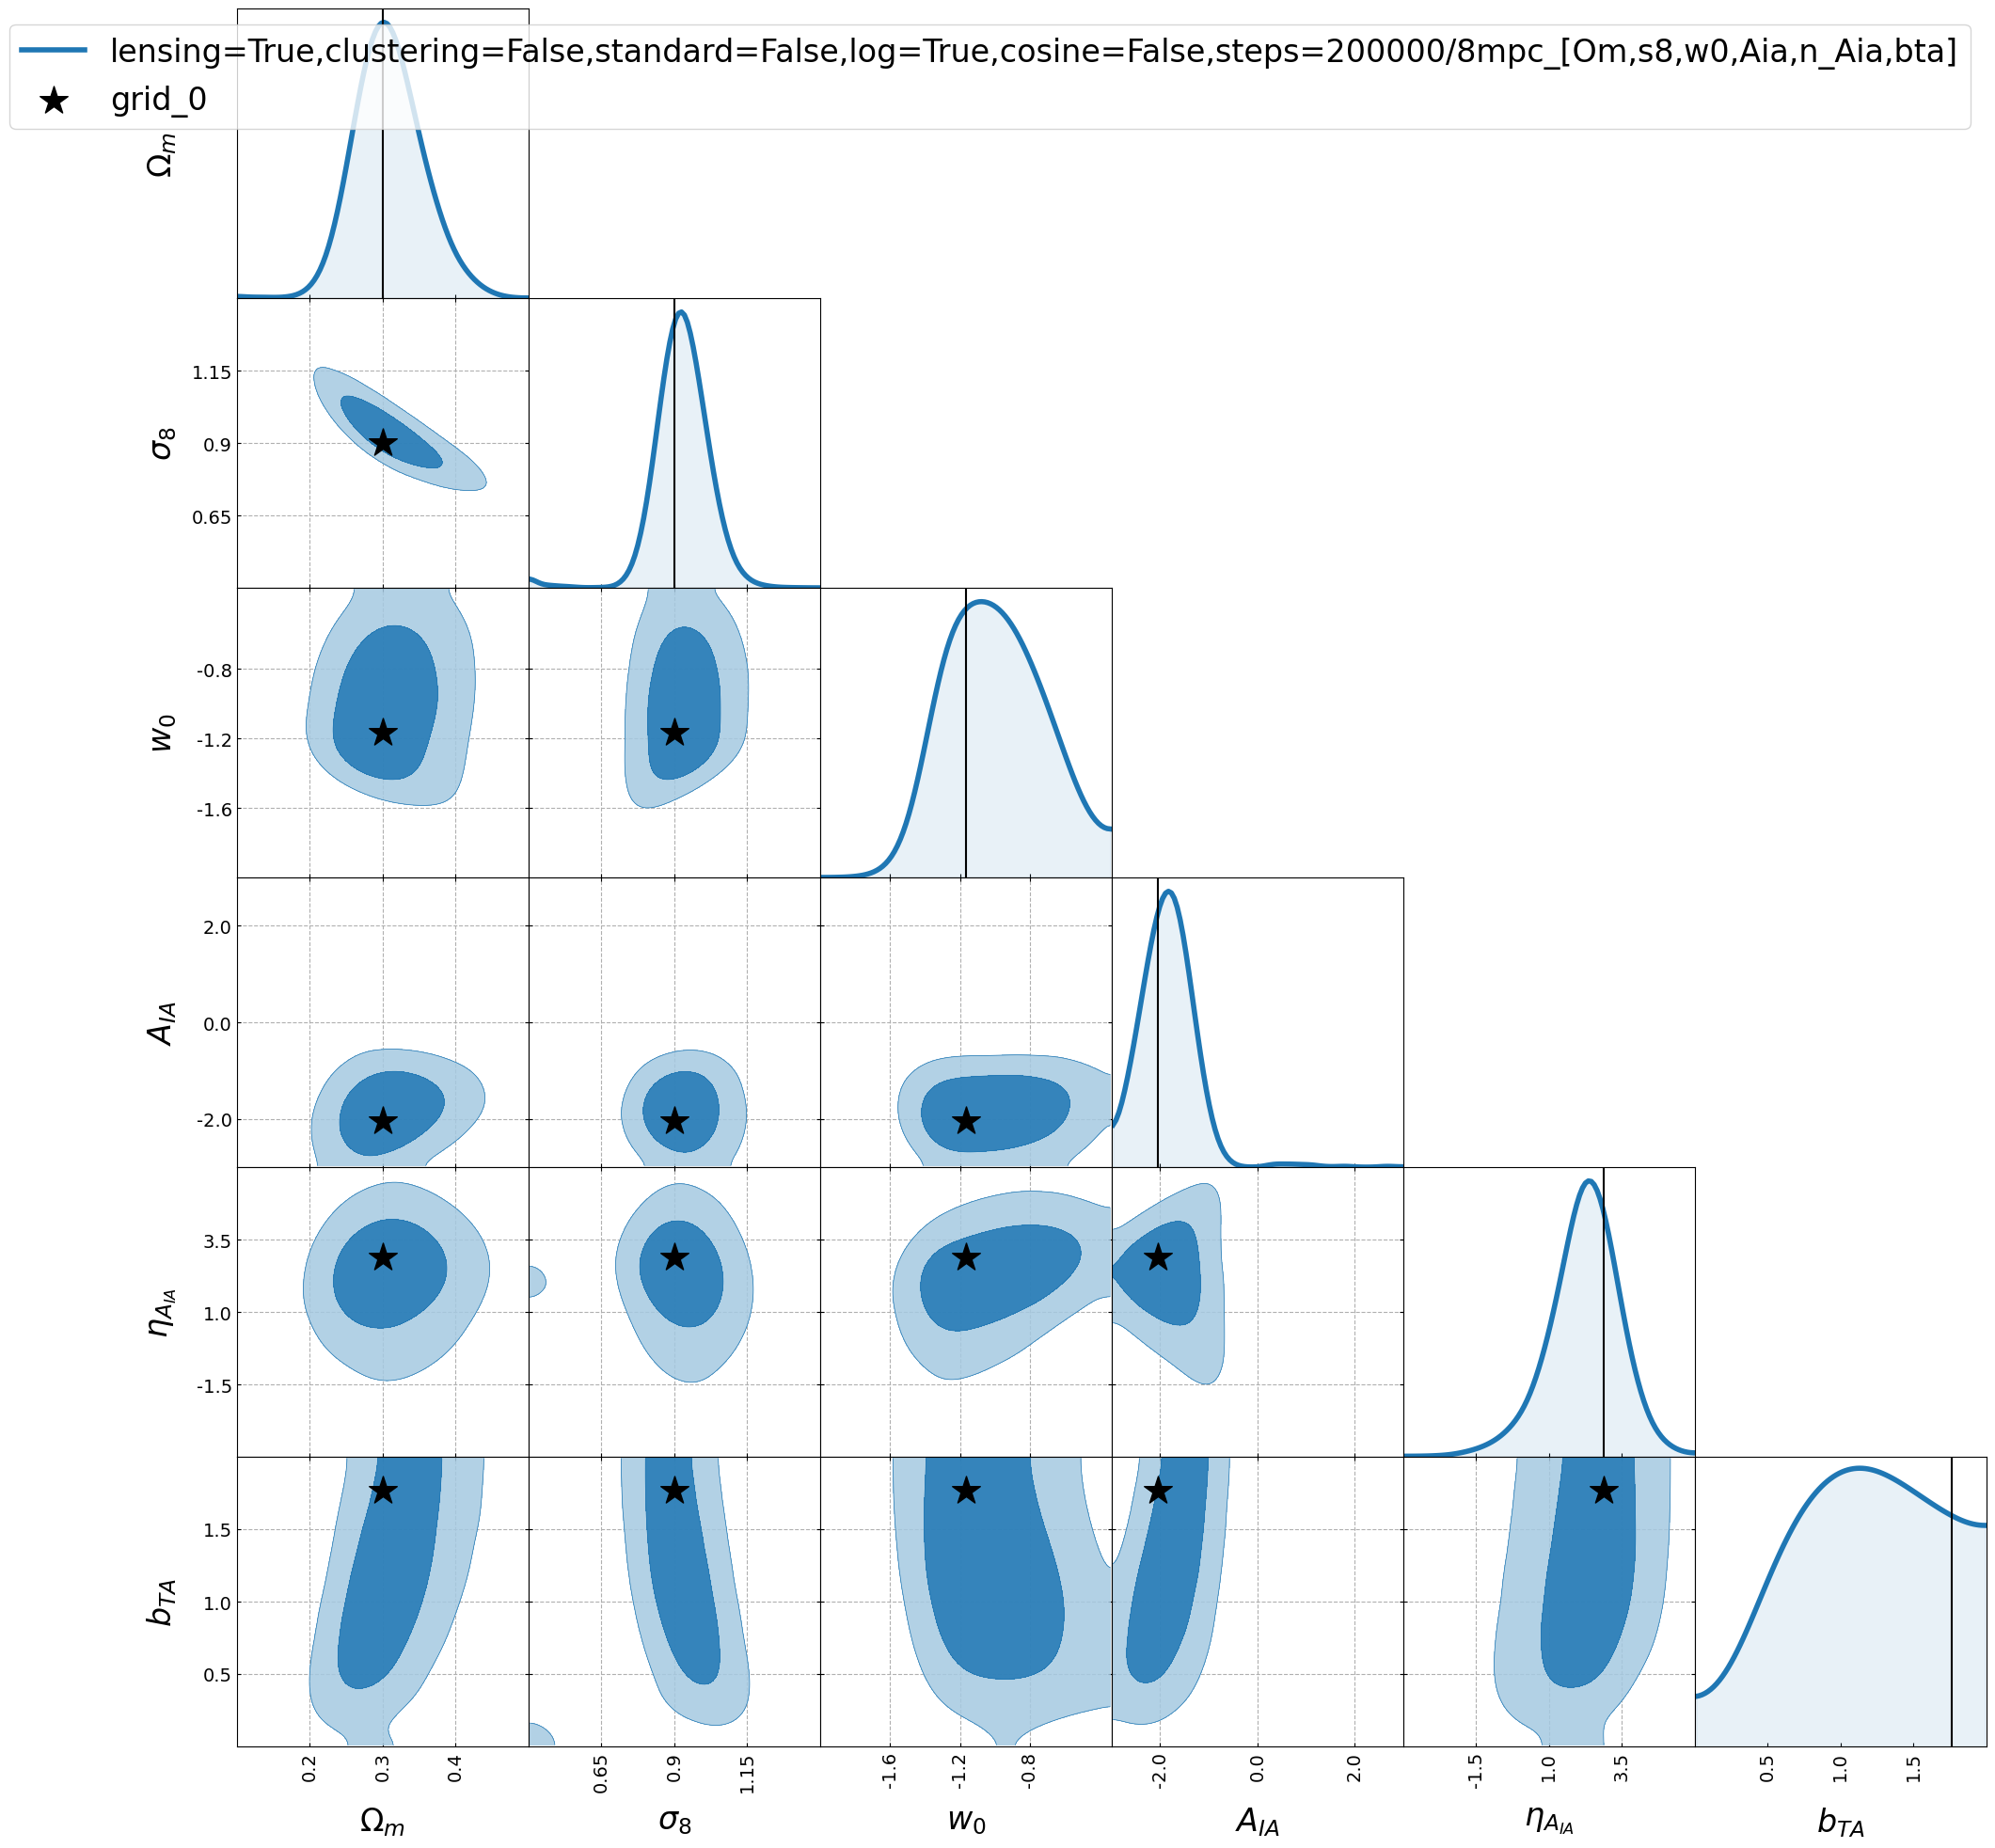

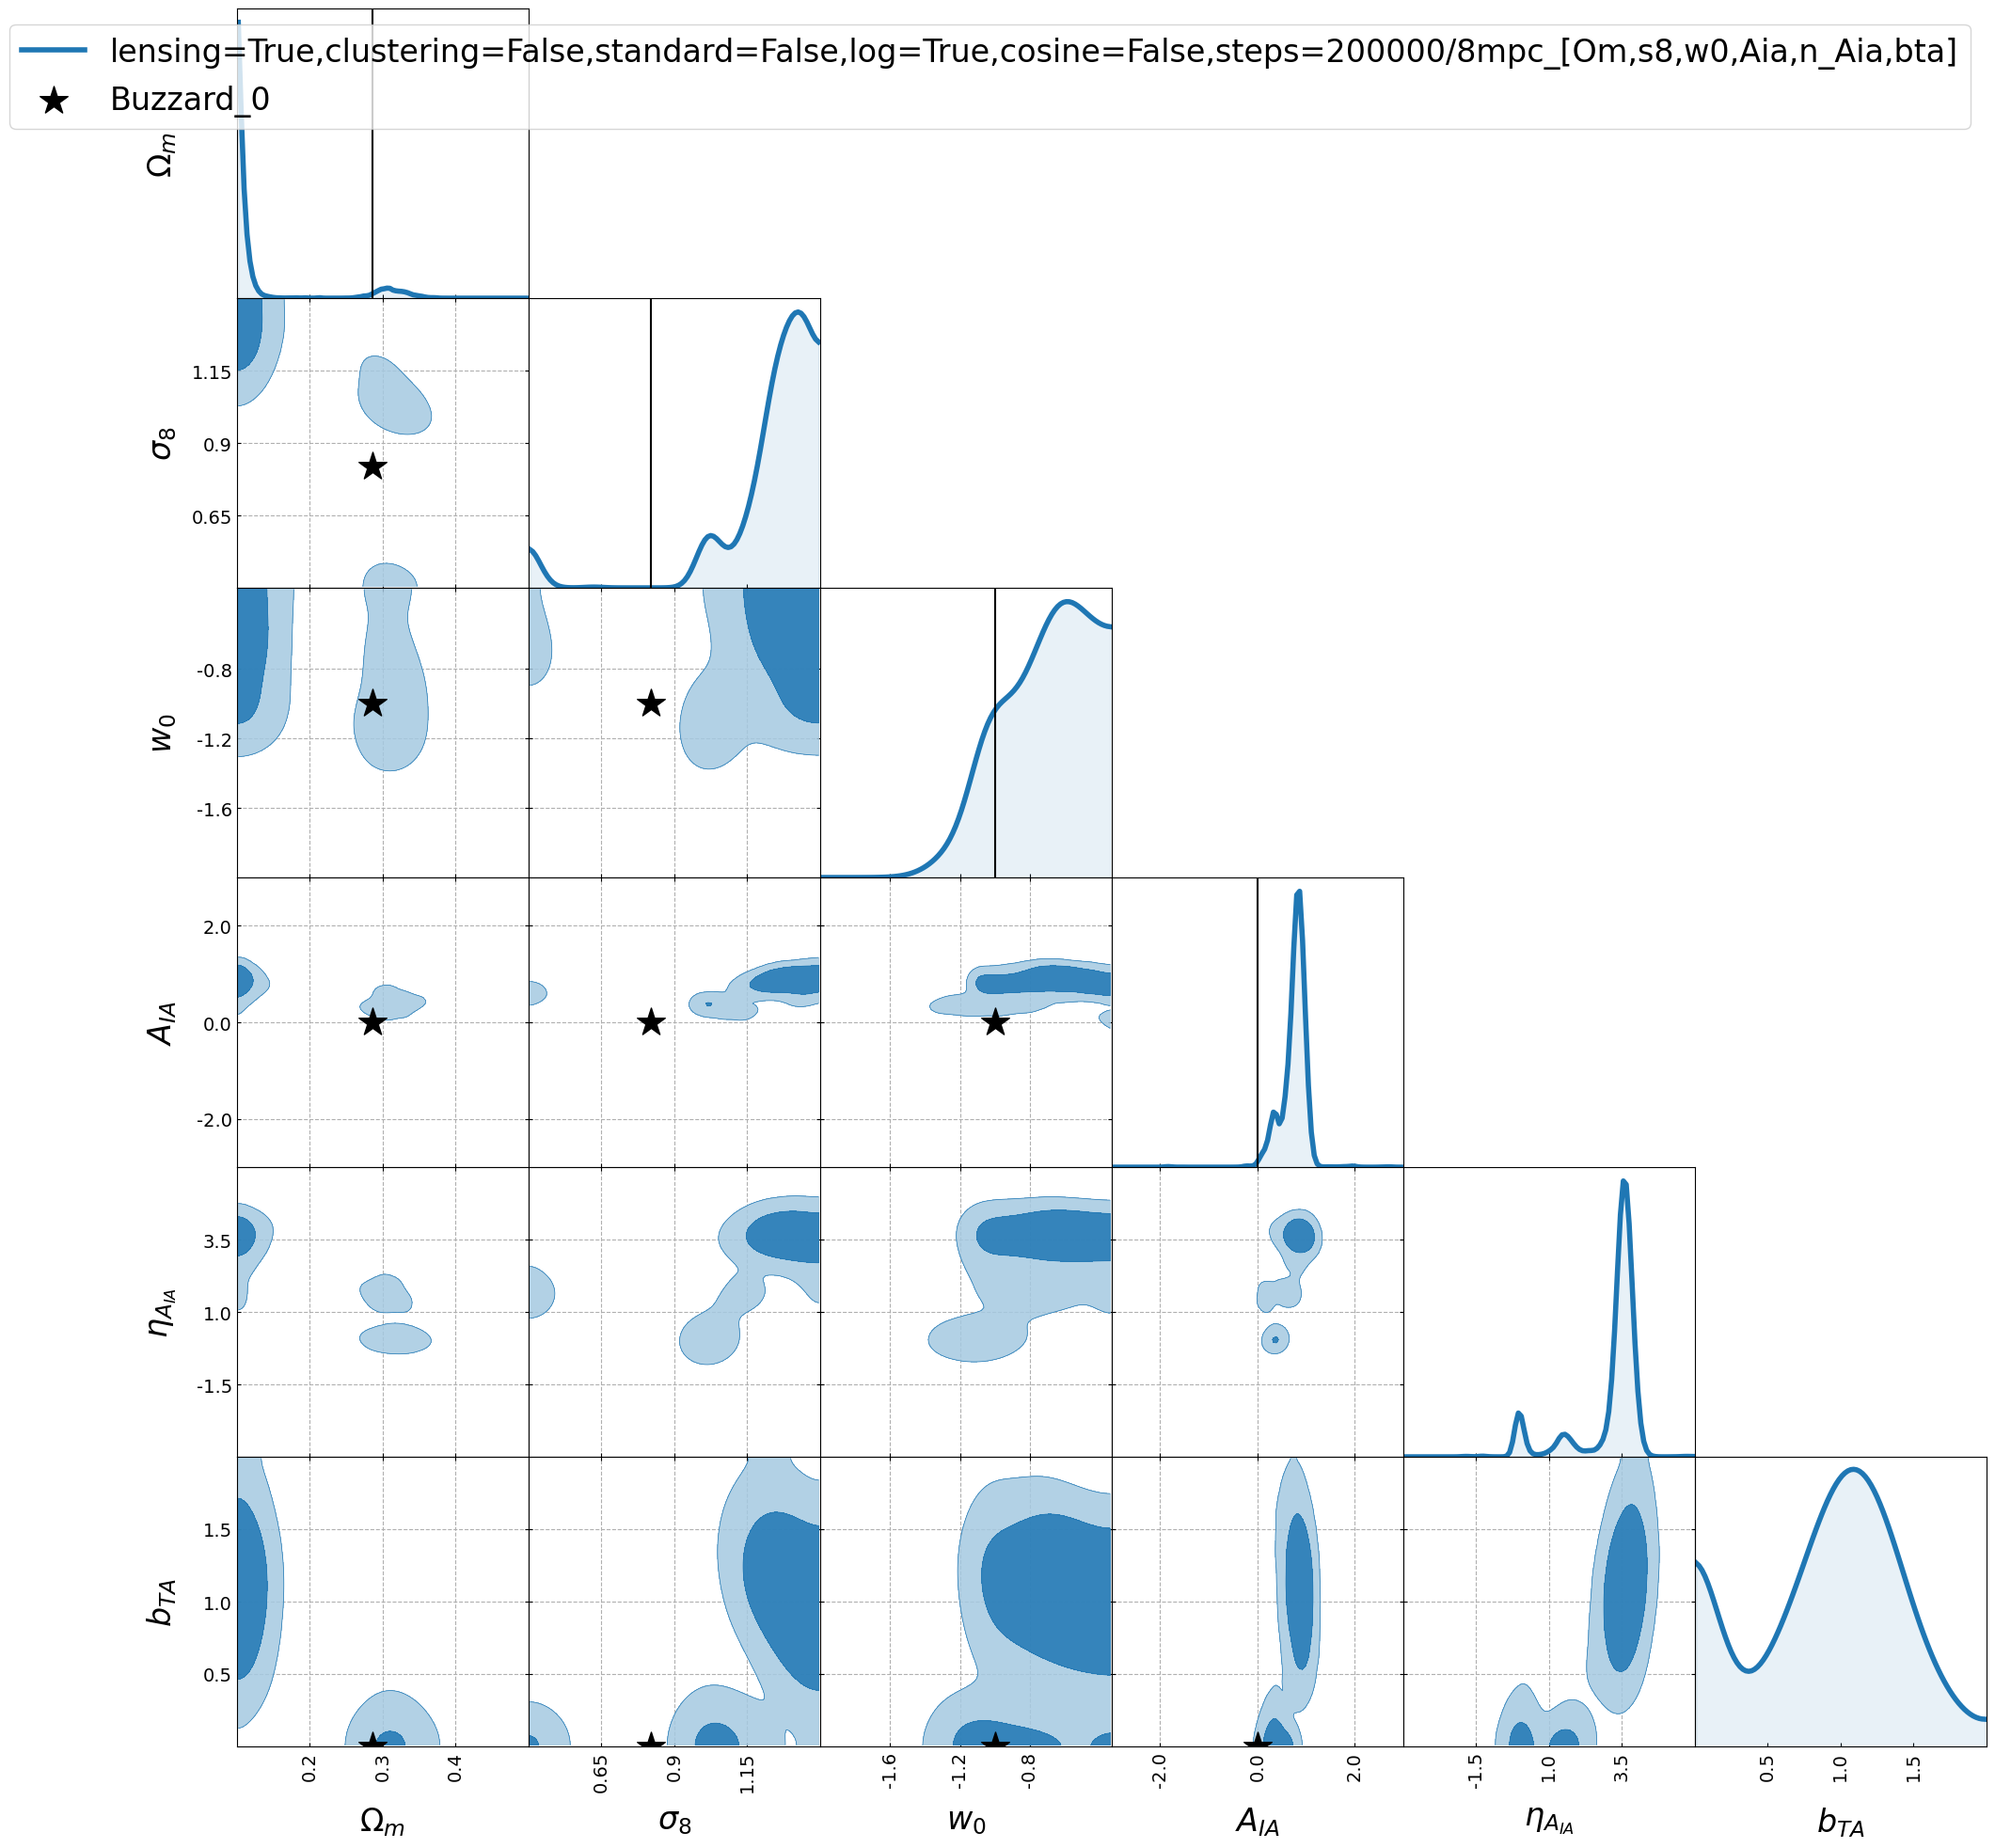

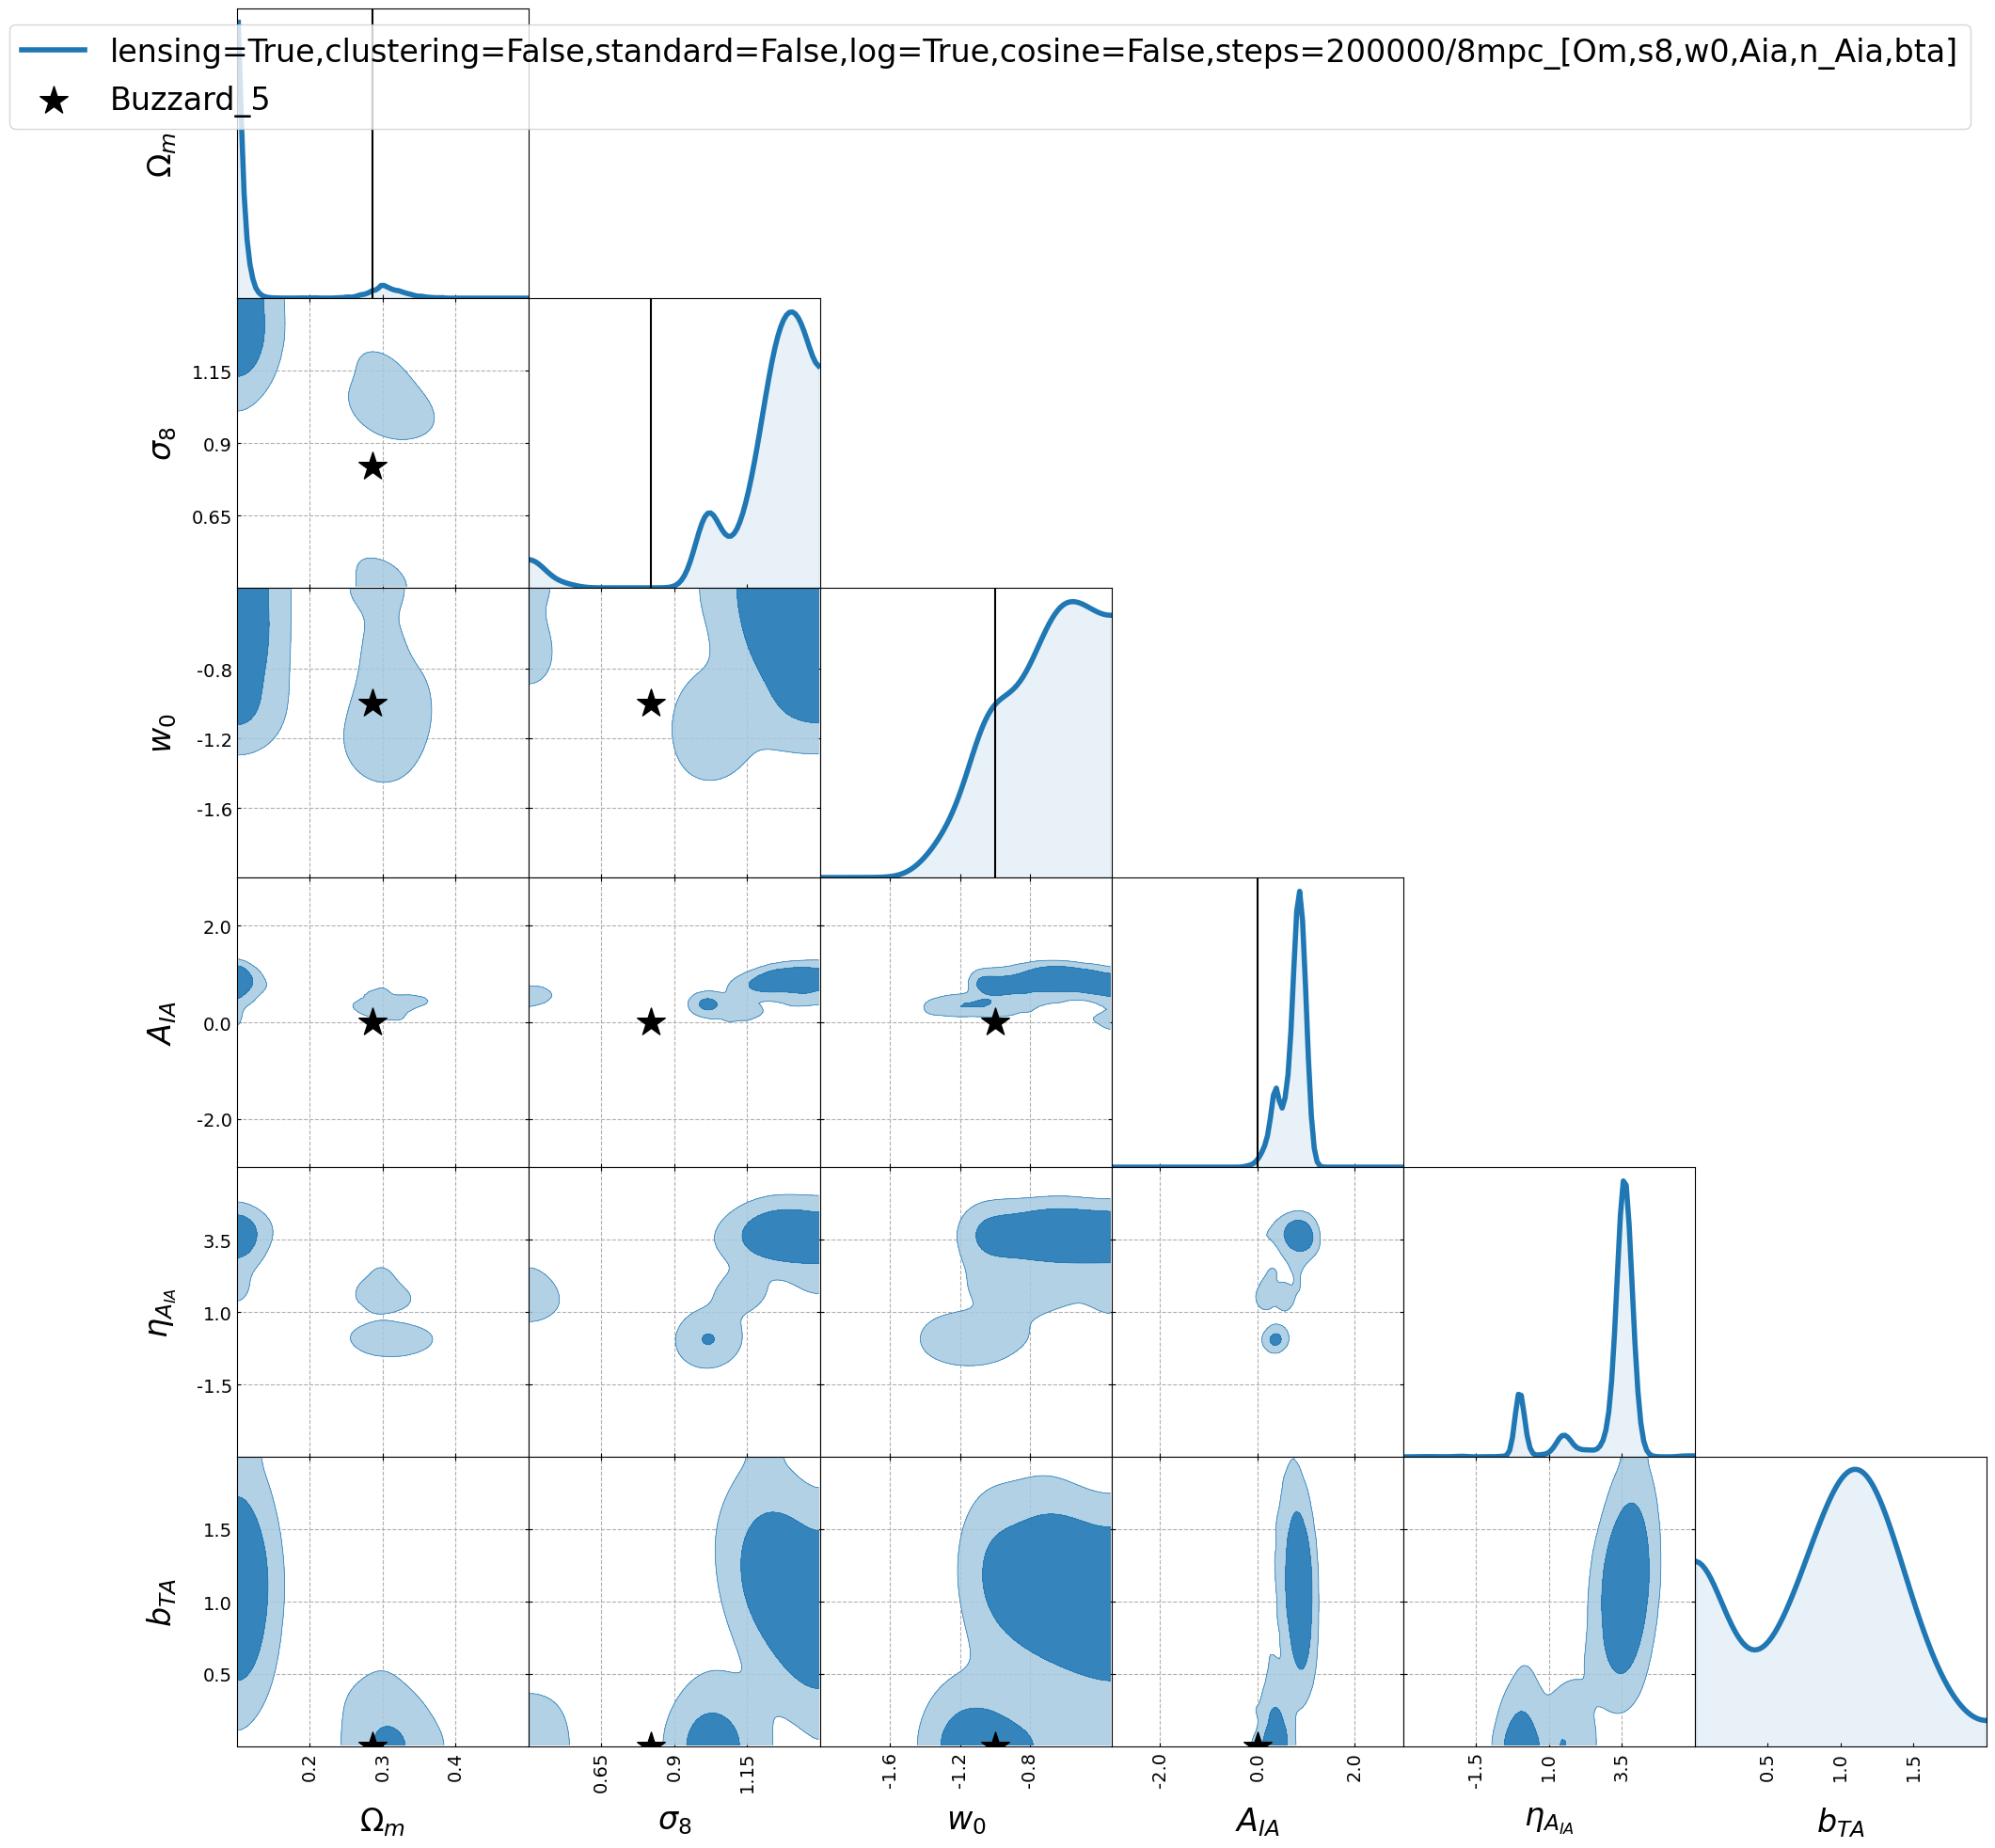

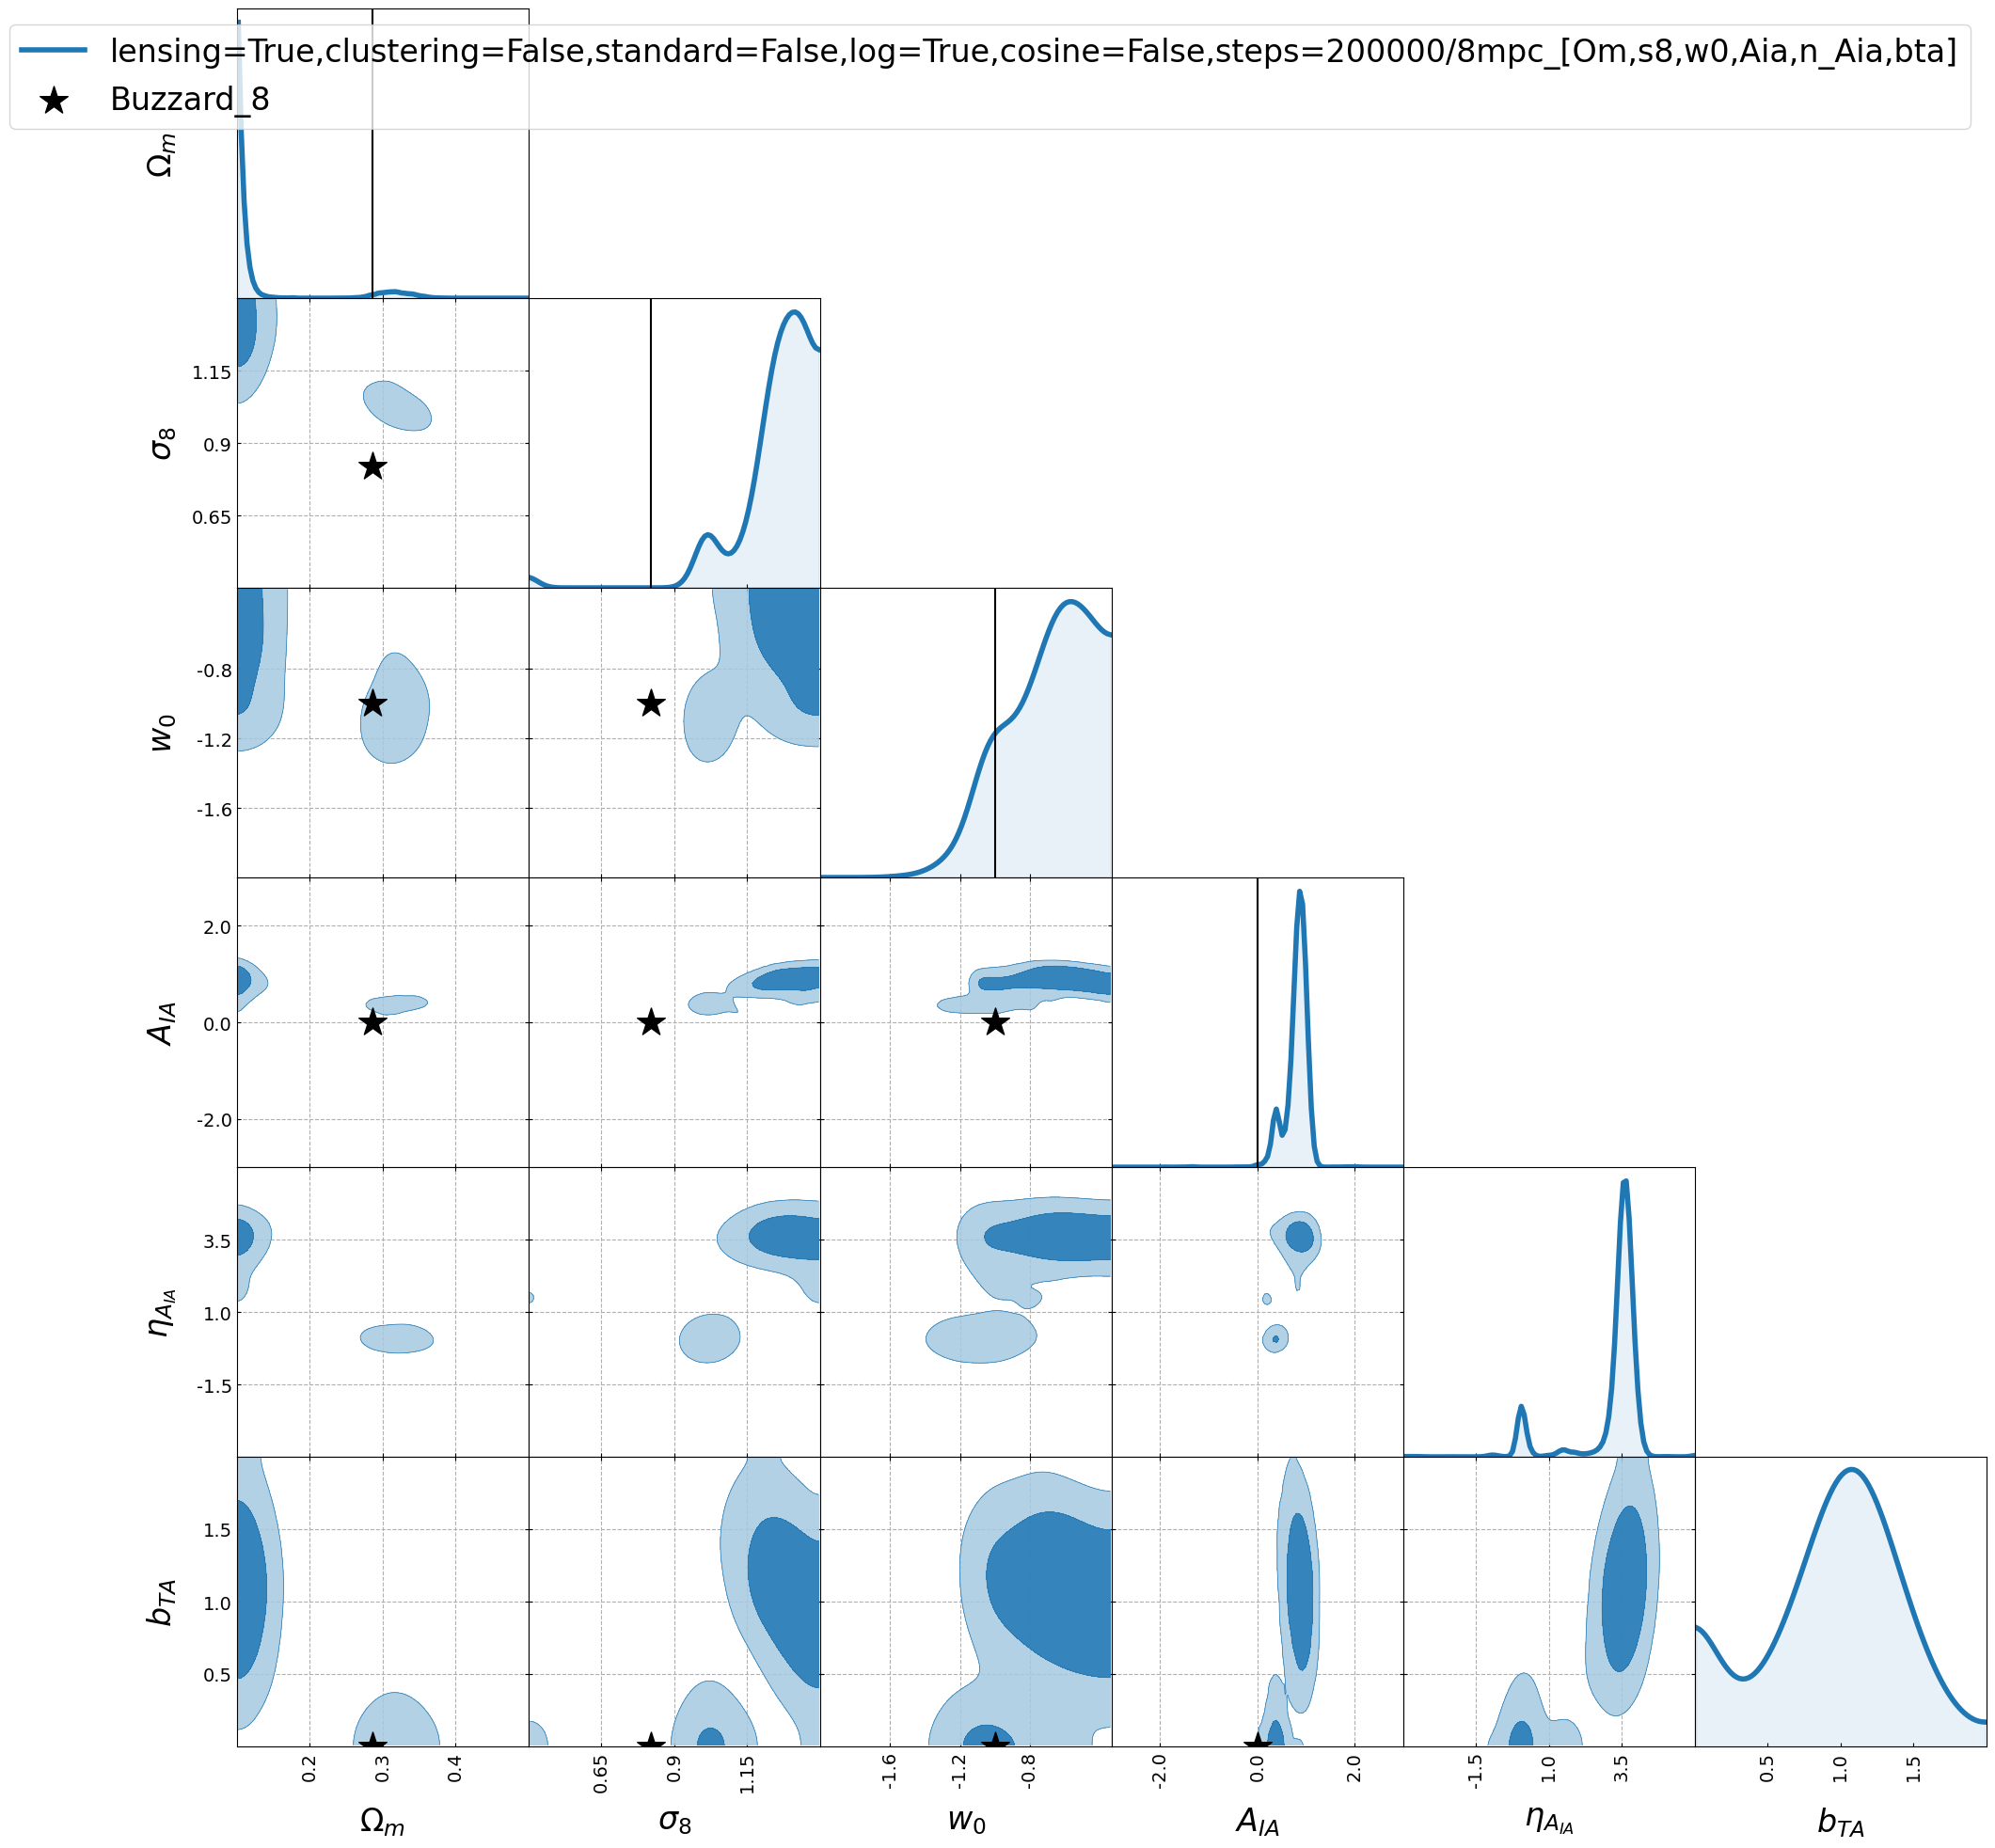

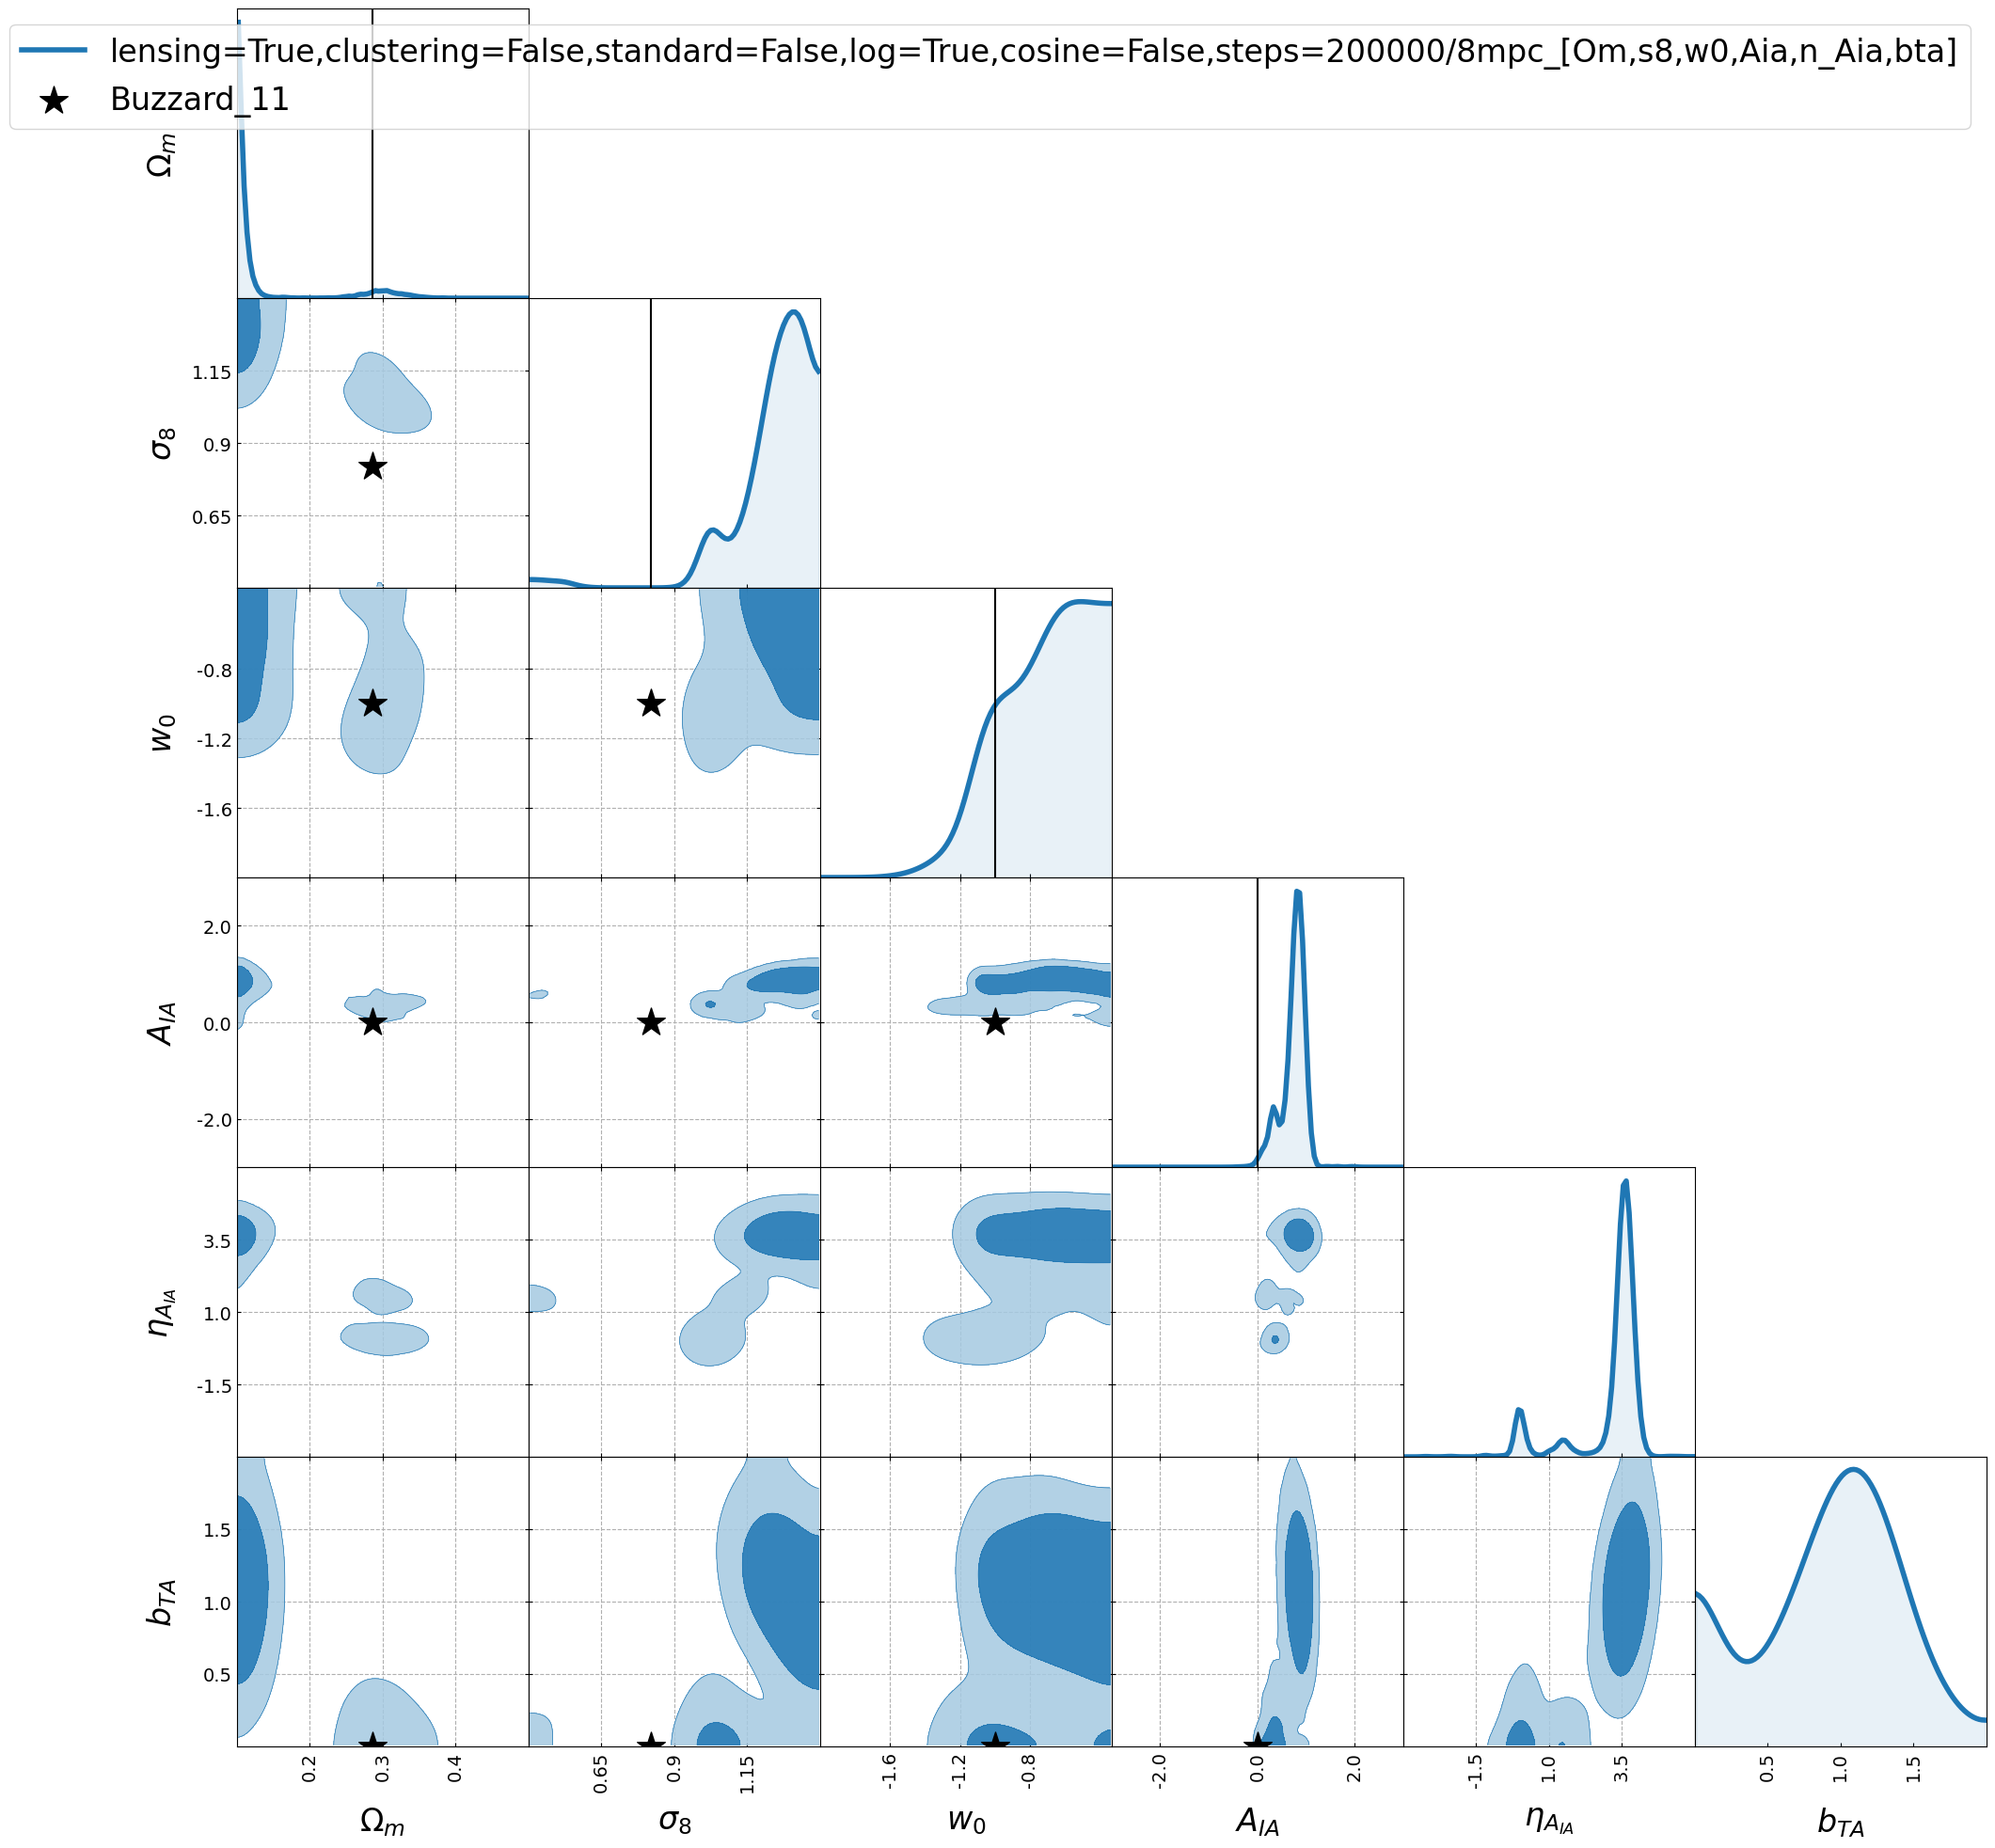

In [54]:
extra_label = ""
# extra_label = "Om=0.3"
# extra_label = f"_n{n_examples}_i{i_examples}_mocks"
# extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_mocks"

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    # print(obs_dict[key]["pred"])
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_burnin_steps=500,
        n_samples=1024*1000,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key+extra_label,
        with_des_chain=False,
    )

### sample the posterior directly

In [ ]:
# extra_label = ""

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     # posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=10_000, batch_size=None, return_numpy=True)
#     posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=100_000, batch_size=None, return_numpy=True)
#     posterior_samples = np.squeeze(posterior_samples)
    
#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )
    
#     samples_file = os.path.join(model.model_dir, f"chain_{key}.npy")
#     print(samples_file)
#     np.save(samples_file, posterior_samples)

In [ ]:
# extra_label = "_16_mocks"

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     posterior_samples = model.sample_posterior(
#         obs_dict[key]["pred"],
#         label=key+extra_label,
#         n_walkers=1024,
#         n_burnin_steps=500,
#         n_samples=1024*500,
#     )

#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )

#     # model.plot_contours(
#     #     posterior_samples,
#     #     obs_point=obs_dict[key]["point"],
#     #     obs_label=key,
#     #     label=key+extra_label,
#     #     with_des_chain=False,
#     # )

# old